In [12]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

In [13]:
possible_paths = [
    Path.cwd() / "prices.txt",
    Path.cwd().parent / "prices.txt",
]

data_path = next(
    (path for path in possible_paths if path.exists()),
    None,
)

if data_path is None:
    raise FileNotFoundError(
        f"Could not find prices.txt. Current directory: {Path.cwd()}"
    )

prices = pd.read_csv(
    data_path,
    sep=r"\s+",
    header=0,
)

prices.index.name = "day"

print("Loaded from:", data_path.resolve())
print("Shape:", prices.shape)

display(prices.head())

Loaded from: /Users/akhilmathur/Documents/Projects/susquehenna_algothon_TeamLynfield/prices.txt
Shape: (1000, 51)


,ALGO,AENO,LSST,SRNA,ELLT,AMRP,OTCS,HETT,HUXZ,DUCT,...,BLBT,BENI,ITPA,HTRK,NGTE,ILVX,FCSG,FARS,MHRM,EAFC
day,,,,,,,,,,,,,,,,,,,,,
0,100.00,116.51,113.55,134.23,64.12,25.05,14.68,59.24,83.62,19.71,...,52.23,32.37,18.82,10.86,52.65,32.58,27.46,66.43,22.41,45.08
1,98.49,112.94,114.53,133.21,62.74,23.96,14.55,58.28,79.94,19.22,...,52.73,32.25,18.41,10.77,49.71,31.66,26.47,64.66,22.10,44.28
2,97.83,112.70,112.17,132.80,61.61,23.30,14.69,57.97,81.20,19.22,...,53.23,32.23,18.22,10.69,50.53,30.84,25.28,64.19,20.87,45.30
3,98.02,112.26,116.09,133.16,63.55,23.47,14.43,57.02,81.82,19.39,...,52.67,32.20,18.22,10.28,51.64,30.95,24.60,62.80,20.95,46.32
4,99.13,113.59,119.58,137.20,63.64,23.61,14.61,58.78,83.01,19.91,...,53.59,32.33,18.25,10.50,53.57,31.49,25.66,63.94,20.72,45.56


In [14]:
prices = prices.apply(
    pd.to_numeric,
    errors="raise",
)

missing_values = prices.isna().sum().sum()
infinite_values = np.isinf(prices.to_numpy()).sum()

print("Number of days:", prices.shape[0])
print("Number of assets:", prices.shape[1])
print("Missing values:", missing_values)
print("Infinite values:", infinite_values)
print("\nAssets:")
print(prices.columns.tolist())

Number of days: 1000
Number of assets: 51
Missing values: 0
Infinite values: 0

Assets:
['ALGO', 'AENO', 'LSST', 'SRNA', 'ELLT', 'AMRP', 'OTCS', 'HETT', 'HUXZ', 'DUCT', 'SMAH', 'NPCK', 'MSDP', 'EORC', 'CUBO', 'HRET', 'ANSO', 'DIHO', 'RTTH', 'SPLZ', 'NWIG', 'MMBT', 'MDGI', 'AGVF', 'RRES', 'CTGI', 'ALUT', 'ACAC', 'SRTX', 'GARI', 'RCRI', 'ACIX', 'CCNS', 'MTNS', 'IHOZ', 'NAYO', 'FWWG', 'EELT', 'HRND', 'AETS', 'ULXY', 'BLBT', 'BENI', 'ITPA', 'HTRK', 'NGTE', 'ILVX', 'FCSG', 'FARS', 'MHRM', 'EAFC']


In [15]:
ASSET = "AENO"

if ASSET not in prices.columns:
    raise ValueError(f"{ASSET} is not present in the dataset.")

asset_prices = prices[ASSET].copy()

print("Selected asset:", ASSET)
display(asset_prices.head())

Selected asset: AENO


day
0    116.51
1    112.94
2    112.70
3    112.26
4    113.59
Name: AENO, dtype: float64

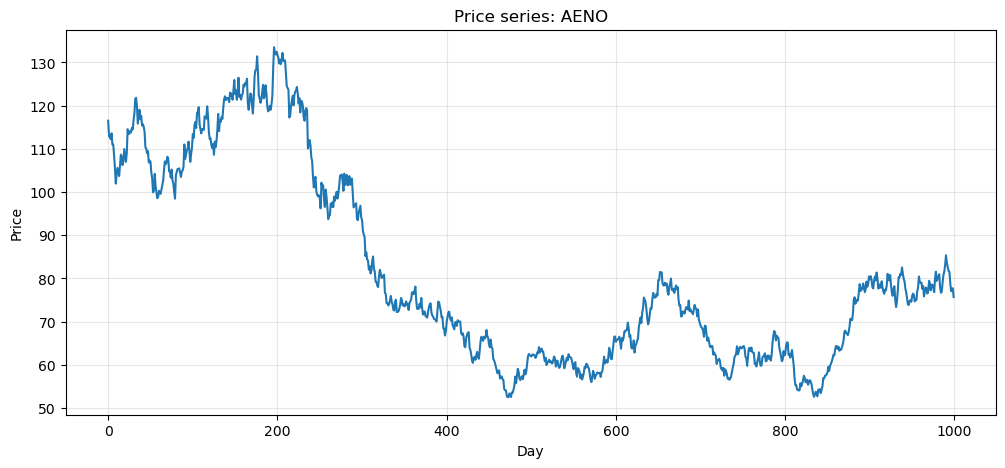

In [16]:
plt.figure(figsize=(12, 5))

plt.plot(asset_prices)

plt.title(f"Price series: {ASSET}")
plt.xlabel("Day")
plt.ylabel("Price")
plt.grid(alpha=0.3)

plt.show()

In [17]:
asset_returns = (
    asset_prices
    .pct_change()
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
)

print("Number of returns:", len(asset_returns))

display(asset_returns.head())

Number of returns: 999


day
1   -0.030641
2   -0.002125
3   -0.003904
4    0.011847
5   -0.023241
Name: AENO, dtype: float64

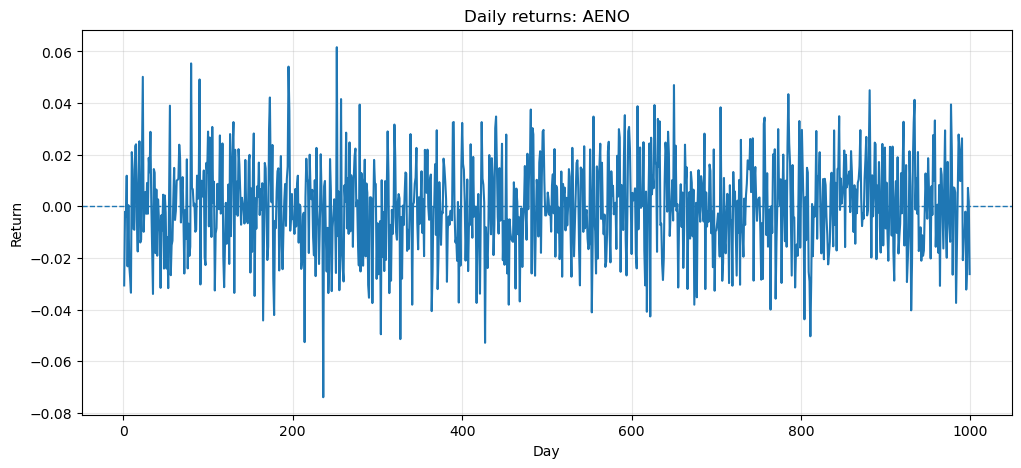

In [18]:
plt.figure(figsize=(12, 5))

plt.plot(asset_returns)
plt.axhline(0, linestyle="--", linewidth=1)

plt.title(f"Daily returns: {ASSET}")
plt.xlabel("Day")
plt.ylabel("Return")
plt.grid(alpha=0.3)

plt.show()

In [19]:
N_LAGS = 20

lagged_data = pd.DataFrame(
    index=asset_returns.index
)

for lag in range(1, N_LAGS + 1):
    lagged_data[f"lag_{lag}"] = asset_returns.shift(lag)

lagged_data["target"] = asset_returns

lagged_data = lagged_data.dropna()

print("Lagged dataset shape:", lagged_data.shape)

display(lagged_data.head())

Lagged dataset shape: (979, 21)


,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,lag_8,lag_9,lag_10,...,lag_12,lag_13,lag_14,lag_15,lag_16,lag_17,lag_18,lag_19,lag_20,target
day,,,,,,,,,,,,,,,,,,,,,
21,-0.014008,0.025177,0.009413,-0.017479,-0.004969,0.024029,0.023337,-0.009078,-0.008808,0.014315,...,-0.033466,-0.027476,-0.022883,0.000451,-0.023241,0.011847,-0.003904,-0.002125,-0.030641,-0.012915
22,-0.012915,-0.014008,0.025177,0.009413,-0.017479,-0.004969,0.024029,0.023337,-0.009078,-0.008808,...,0.020991,-0.033466,-0.027476,-0.022883,0.000451,-0.023241,0.011847,-0.003904,-0.002125,0.019346
23,0.019346,-0.012915,-0.014008,0.025177,0.009413,-0.017479,-0.004969,0.024029,0.023337,-0.009078,...,0.014315,0.020991,-0.033466,-0.027476,-0.022883,0.000451,-0.023241,0.011847,-0.003904,0.050151
24,0.050151,0.019346,-0.012915,-0.014008,0.025177,0.009413,-0.017479,-0.004969,0.024029,0.023337,...,-0.008808,0.014315,0.020991,-0.033466,-0.027476,-0.022883,0.000451,-0.023241,0.011847,-0.009866
25,-0.009866,0.050151,0.019346,-0.012915,-0.014008,0.025177,0.009413,-0.017479,-0.004969,0.024029,...,-0.009078,-0.008808,0.014315,0.020991,-0.033466,-0.027476,-0.022883,0.000451,-0.023241,0.000705


In [20]:
X = lagged_data.drop(columns="target")
y = lagged_data["target"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (979, 20)
y shape: (979,)


In [21]:
SPLIT_DAY = 800

training_mask = X.index < SPLIT_DAY
testing_mask = X.index >= SPLIT_DAY

X_train = X.loc[training_mask]
X_test = X.loc[testing_mask]

y_train = y.loc[training_mask]
y_test = y.loc[testing_mask]

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print(
    "\nTraining target days:",
    X_train.index.min(),
    "to",
    X_train.index.max(),
)

print(
    "Testing target days:",
    X_test.index.min(),
    "to",
    X_test.index.max(),
)

Training samples: 779
Testing samples: 200

Training target days: 21 to 799
Testing target days: 800 to 999


In [22]:
training_covariance = X_train.cov()

display(training_covariance.round(8))

,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,lag_8,lag_9,lag_10,lag_11,lag_12,lag_13,lag_14,lag_15,lag_16,lag_17,lag_18,lag_19,lag_20
lag_1,3.351300e-04,8.270000e-06,-1.498000e-05,-0.000015,0.000010,0.000001,-0.000003,-0.000004,-0.000011,-0.000013,0.000023,0.000018,0.000018,0.000034,-0.000017,-0.000011,-0.000020,-1.600000e-07,-1.135000e-05,9.550000e-06
lag_2,8.270000e-06,3.345300e-04,8.360000e-06,-0.000015,-0.000015,0.000011,0.000003,-0.000003,-0.000004,-0.000012,-0.000011,0.000022,0.000016,0.000016,0.000032,-0.000018,-0.000010,-2.100000e-05,3.500000e-07,-1.241000e-05
lag_3,-1.498000e-05,8.360000e-06,3.346200e-04,0.000008,-0.000015,-0.000014,0.000012,0.000003,-0.000003,-0.000004,-0.000011,-0.000011,0.000021,0.000016,0.000015,0.000031,-0.000018,-9.910000e-06,-2.092000e-05,-5.000000e-08
lag_4,-1.502000e-05,-1.473000e-05,8.270000e-06,0.000335,0.000008,-0.000016,-0.000015,0.000012,0.000003,-0.000003,-0.000005,-0.000010,-0.000010,0.000023,0.000017,0.000017,0.000031,-1.787000e-05,-1.019000e-05,-2.023000e-05
lag_5,9.590000e-06,-1.455000e-05,-1.469000e-05,0.000008,0.000334,0.000008,-0.000016,-0.000015,0.000012,0.000004,-0.000003,-0.000005,-0.000010,-0.000010,0.000023,0.000017,0.000016,3.080000e-05,-1.809000e-05,-9.990000e-06
lag_6,1.160000e-06,1.114000e-05,-1.412000e-05,-0.000016,0.000008,0.000335,0.000008,-0.000017,-0.000016,0.000013,0.000004,-0.000004,-0.000005,-0.000010,-0.000009,0.000023,0.000017,1.630000e-05,3.047000e-05,-1.901000e-05
lag_7,-2.590000e-06,3.290000e-06,1.167000e-05,-0.000015,-0.000016,0.000008,0.000334,0.000007,-0.000017,-0.000015,0.000012,0.000002,-0.000005,-0.000005,-0.000008,-0.000008,0.000023,1.771000e-05,1.574000e-05,2.962000e-05
lag_8,-3.530000e-06,-2.700000e-06,3.200000e-06,0.000012,-0.000015,-0.000017,0.000007,0.000334,0.000007,-0.000017,-0.000015,0.000013,0.000003,-0.000004,-0.000005,-0.000008,-0.000009,2.305000e-05,1.766000e-05,1.608000e-05
lag_9,-1.133000e-05,-3.640000e-06,-2.780000e-06,0.000003,0.000012,-0.000016,-0.000017,0.000007,0.000334,0.000007,-0.000018,-0.000015,0.000013,0.000003,-0.000004,-0.000004,-0.000008,-8.560000e-06,2.300000e-05,1.799000e-05
lag_10,-1.273000e-05,-1.155000e-05,-3.570000e-06,-0.000003,0.000004,0.000013,-0.000015,-0.000017,0.000007,0.000334,0.000008,-0.000018,-0.000016,0.000012,0.000002,-0.000005,-0.000004,-8.510000e-06,-8.320000e-06,2.240000e-05


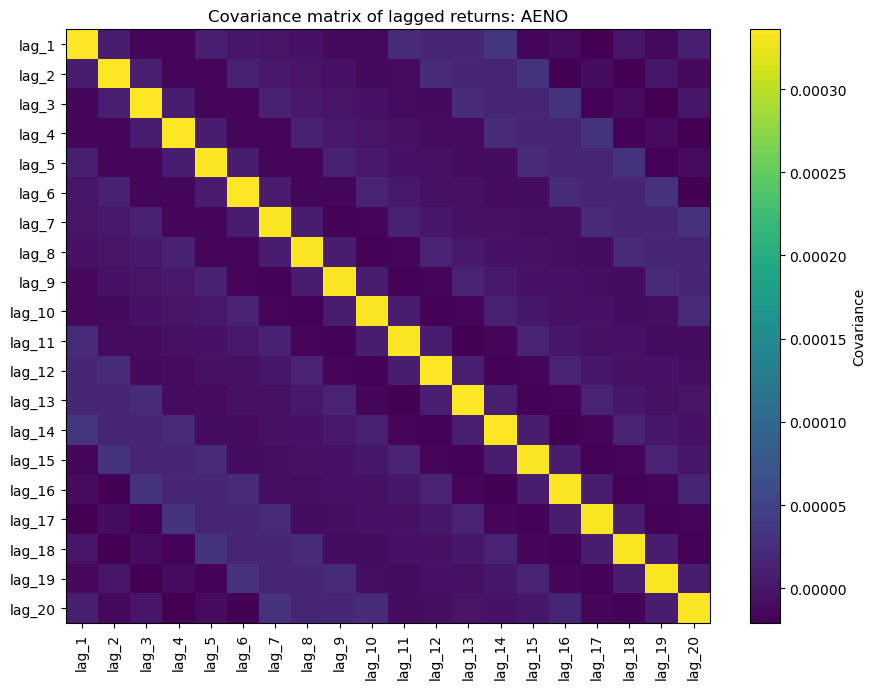

In [23]:
plt.figure(figsize=(9, 7))

plt.imshow(
    training_covariance,
    aspect="auto",
)

plt.colorbar(label="Covariance")

plt.xticks(
    range(N_LAGS),
    X_train.columns,
    rotation=90,
)

plt.yticks(
    range(N_LAGS),
    X_train.columns,
)

plt.title(f"Covariance matrix of lagged returns: {ASSET}")
plt.tight_layout()

plt.show()

In [24]:
scaler_for_analysis = StandardScaler()

X_train_scaled = scaler_for_analysis.fit_transform(
    X_train
)

pca_full = PCA()

pca_full.fit(
    X_train_scaled
)

explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

pca_summary = pd.DataFrame({
    "component": np.arange(1, N_LAGS + 1),
    "explained_variance": explained_variance,
    "cumulative_variance": cumulative_variance,
})

display(pca_summary)

,component,explained_variance,cumulative_variance
0,1,0.064572,0.064572
1,2,0.063694,0.128267
2,3,0.060685,0.188952
3,4,0.059625,0.248577
4,5,0.059084,0.307661
5,6,0.057202,0.364863
6,7,0.054824,0.419687
7,8,0.054548,0.474235
8,9,0.053332,0.527567
9,10,0.050730,0.578298


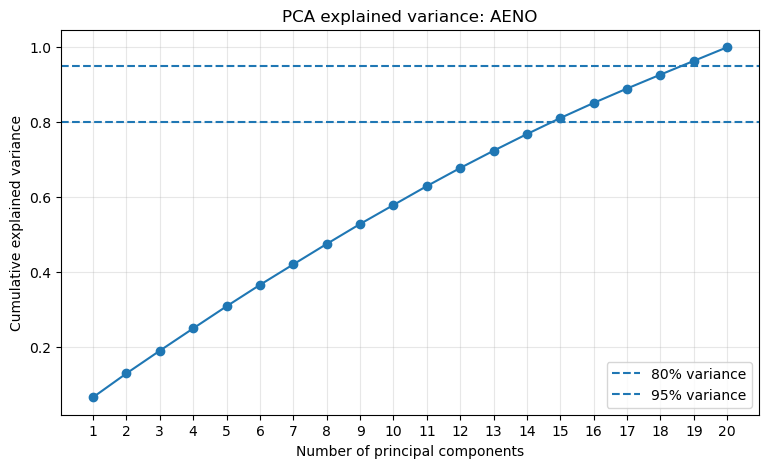

In [25]:
plt.figure(figsize=(9, 5))

plt.plot(
    pca_summary["component"],
    pca_summary["cumulative_variance"],
    marker="o",
)

plt.axhline(
    0.80,
    linestyle="--",
    label="80% variance",
)

plt.axhline(
    0.95,
    linestyle="--",
    label="95% variance",
)

plt.xlabel("Number of principal components")
plt.ylabel("Cumulative explained variance")
plt.title(f"PCA explained variance: {ASSET}")

plt.xticks(range(1, N_LAGS + 1))
plt.grid(alpha=0.3)
plt.legend()

plt.show()

In [26]:
pca_regression_pipeline = Pipeline([
    (
        "scaler",
        StandardScaler(),
    ),
    (
        "pca",
        PCA(),
    ),
    (
        "regression",
        LinearRegression(),
    ),
])

In [27]:
time_series_cv = TimeSeriesSplit(
    n_splits=5
)

parameter_grid = {
    "pca__n_components": list(
        range(1, N_LAGS + 1)
    )
}

pca_search = GridSearchCV(
    estimator=pca_regression_pipeline,
    param_grid=parameter_grid,
    scoring="neg_mean_squared_error",
    cv=time_series_cv,
    n_jobs=-1,
)

pca_search.fit(
    X_train,
    y_train,
)

best_number_of_components = (
    pca_search.best_params_["pca__n_components"]
)

print(
    "Best number of principal components:",
    best_number_of_components,
)

print(
    "Best cross-validation RMSE:",
    np.sqrt(-pca_search.best_score_),
)

Best number of principal components: 15
Best cross-validation RMSE: 0.01837165085417484


In [28]:
cv_results = pd.DataFrame(
    pca_search.cv_results_
)

cv_summary = pd.DataFrame({
    "number_of_components":
        cv_results["param_pca__n_components"].astype(int),

    "cross_validation_RMSE":
        np.sqrt(-cv_results["mean_test_score"]),
})

cv_summary = cv_summary.sort_values(
    "number_of_components"
)

display(cv_summary)

,number_of_components,cross_validation_RMSE
0,1,0.018469
1,2,0.018469
2,3,0.018491
3,4,0.018560
4,5,0.018610
5,6,0.018596
6,7,0.018577
7,8,0.018591
8,9,0.018582
9,10,0.018580


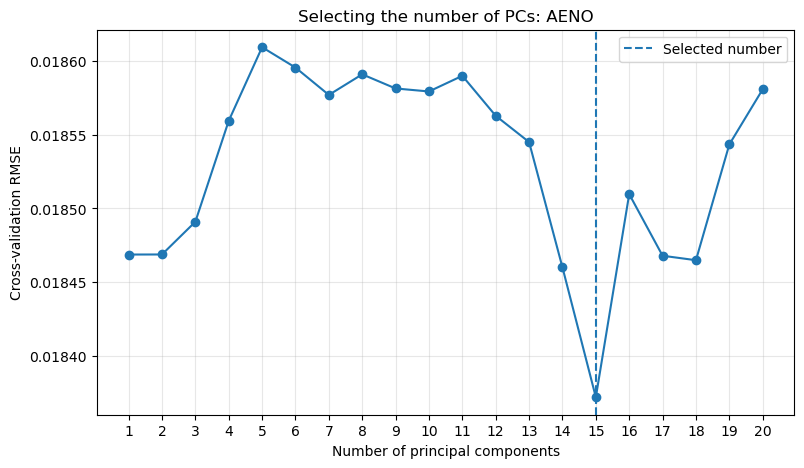

In [29]:
plt.figure(figsize=(9, 5))

plt.plot(
    cv_summary["number_of_components"],
    cv_summary["cross_validation_RMSE"],
    marker="o",
)

plt.axvline(
    best_number_of_components,
    linestyle="--",
    label="Selected number",
)

plt.xlabel("Number of principal components")
plt.ylabel("Cross-validation RMSE")
plt.title(f"Selecting the number of PCs: {ASSET}")

plt.xticks(range(1, N_LAGS + 1))
plt.grid(alpha=0.3)
plt.legend()

plt.show()

In [30]:
best_pca_model = pca_search.best_estimator_

pca_predictions = best_pca_model.predict(
    X_test
)

print("Number of predictions:", len(pca_predictions))

Number of predictions: 200


In [31]:
def evaluate_predictions(
    y_true,
    predictions,
    model_name,
):
    y_true = np.asarray(y_true)
    predictions = np.asarray(predictions)

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            predictions,
        )
    )

    mae = mean_absolute_error(
        y_true,
        predictions,
    )

    r_squared = r2_score(
        y_true,
        predictions,
    )

    directional_accuracy = np.mean(
        np.sign(predictions)
        ==
        np.sign(y_true)
    )

    if np.std(predictions) == 0:
        prediction_correlation = np.nan
    else:
        prediction_correlation = np.corrcoef(
            y_true,
            predictions,
        )[0, 1]

    return {
        "model": model_name,
        "RMSE": rmse,
        "MAE": mae,
        "R_squared": r_squared,
        "directional_accuracy": directional_accuracy,
        "prediction_correlation": prediction_correlation,
    }

In [32]:
zero_predictions = np.zeros(
    len(y_test)
)

In [33]:
mean_predictions = np.full(
    len(y_test),
    y_train.mean(),
)

In [34]:
previous_return_predictions = (
    X_test["lag_1"].to_numpy()
)

In [35]:
raw_regression_model = Pipeline([
    (
        "scaler",
        StandardScaler(),
    ),
    (
        "regression",
        LinearRegression(),
    ),
])

raw_regression_model.fit(
    X_train,
    y_train,
)

raw_regression_predictions = (
    raw_regression_model.predict(X_test)
)

In [36]:
comparison = pd.DataFrame([
    evaluate_predictions(
        y_test,
        zero_predictions,
        "Predict zero",
    ),

    evaluate_predictions(
        y_test,
        mean_predictions,
        "Predict training mean",
    ),

    evaluate_predictions(
        y_test,
        previous_return_predictions,
        "Predict previous return",
    ),

    evaluate_predictions(
        y_test,
        raw_regression_predictions,
        "Regression without PCA",
    ),

    evaluate_predictions(
        y_test,
        pca_predictions,
        "PCA + regression",
    ),
])

comparison = comparison.sort_values(
    "RMSE"
).reset_index(drop=True)

display(comparison)

,model,RMSE,MAE,R_squared,directional_accuracy,prediction_correlation
0,Predict zero,0.017551,0.014405,-0.004226,0.000,NaN
1,Predict training mean,0.017595,0.014423,-0.009251,0.485,-1.525301e-16
2,PCA + regression,0.017762,0.014482,-0.028454,0.530,4.176876e-02
3,Regression without PCA,0.017897,0.014556,-0.044124,0.515,1.696755e-02
4,Predict previous return,0.022873,0.019006,-0.705533,0.490,1.440505e-01


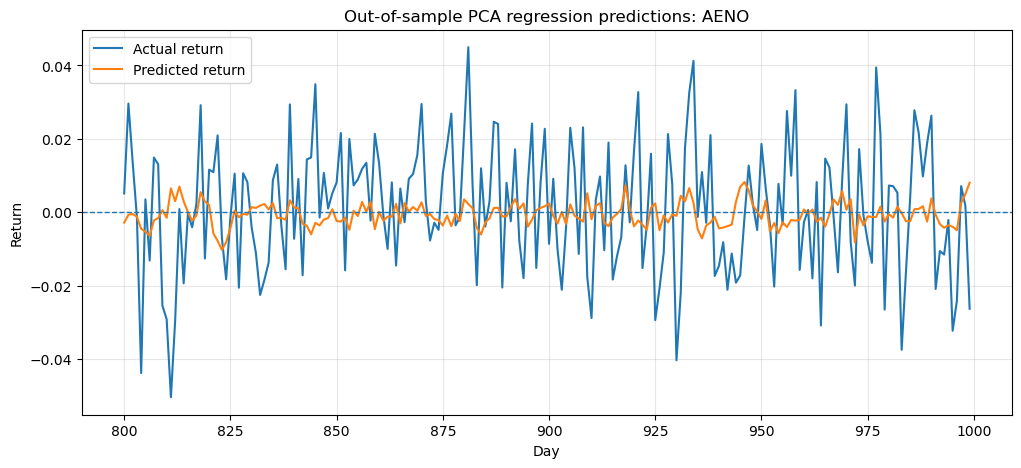

In [37]:
prediction_results = pd.DataFrame(
    {
        "actual_return": y_test,
        "predicted_return": pca_predictions,
    },
    index=y_test.index,
)

plt.figure(figsize=(12, 5))

plt.plot(
    prediction_results.index,
    prediction_results["actual_return"],
    label="Actual return",
)

plt.plot(
    prediction_results.index,
    prediction_results["predicted_return"],
    label="Predicted return",
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1,
)

plt.title(
    f"Out-of-sample PCA regression predictions: {ASSET}"
)

plt.xlabel("Day")
plt.ylabel("Return")
plt.grid(alpha=0.3)
plt.legend()

plt.show()

In [38]:
strategy_results = pd.DataFrame(
    index=y_test.index
)

strategy_results["asset_return"] = y_test

strategy_results["predicted_return"] = (
    pca_predictions
)

strategy_results["position"] = np.sign(
    strategy_results["predicted_return"]
)

strategy_results["strategy_return"] = (
    strategy_results["position"]
    *
    strategy_results["asset_return"]
)

strategy_results["strategy_growth"] = (
    1 + strategy_results["strategy_return"]
).cumprod()

strategy_results["buy_and_hold_growth"] = (
    1 + strategy_results["asset_return"]
).cumprod()

display(strategy_results.head())

,asset_return,predicted_return,position,strategy_return,strategy_growth,buy_and_hold_growth
day,,,,,,
800,0.005148,-0.002799,-1.0,-0.005148,0.994852,1.005148
801,0.029609,-0.000652,-1.0,-0.029609,0.965395,1.034910
802,0.013679,-0.000448,-1.0,-0.013679,0.952189,1.049067
803,-0.001380,-0.001193,-1.0,0.001380,0.953503,1.047619
804,-0.043765,-0.004475,-1.0,0.043765,0.995233,1.001770


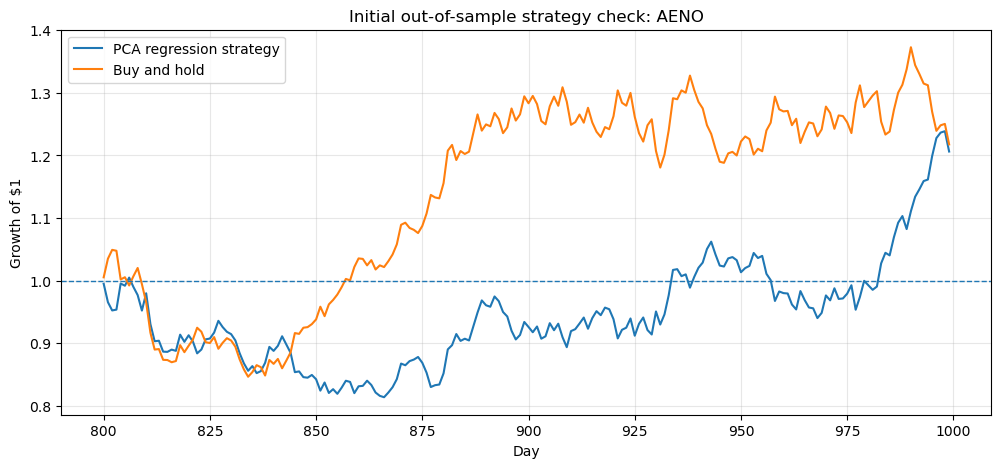

In [39]:
plt.figure(figsize=(12, 5))

plt.plot(
    strategy_results.index,
    strategy_results["strategy_growth"],
    label="PCA regression strategy",
)

plt.plot(
    strategy_results.index,
    strategy_results["buy_and_hold_growth"],
    label="Buy and hold",
)

plt.axhline(
    1,
    linestyle="--",
    linewidth=1,
)

plt.title(
    f"Initial out-of-sample strategy check: {ASSET}"
)

plt.xlabel("Day")
plt.ylabel("Growth of $1")
plt.grid(alpha=0.3)
plt.legend()

plt.show()